# Dataset Setup (Google Colab)

This project uses the CIFAKE dataset from Kaggle.

To reproduce the notebook in Google Colab:

1. Create a Kaggle account.
2. Generate a Kaggle API token (`kaggle.json`).
3. Upload `kaggle.json` to the Colab session.
4. Download the CIFAKE dataset using the Kaggle API.
5. Extract the dataset into the `cifake_data/` directory.

The training code assumes the dataset is available at:

cifake_data/
├── train/
└── test/

In [ ]:
# Uncomment these commands if running in Google Colab

# !pip install kaggle

# from google.colab import files
# files.upload()   # Upload kaggle.json

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# !kaggle datasets download -d <DATASET_NAME>
# !unzip dataset.zip

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder('cifake_data/train', transform=transform)
test_dataset = datasets.ImageFolder('cifake_data/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(train_dataset.classes, len(train_dataset), len(test_dataset))

['FAKE', 'REAL'] 100000 20000


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 0:
            print(f"Epoch {epoch+1}, Batch {i}/{len(train_loader)}, Loss: {loss.item():.4f}")
    print(f"Epoch {epoch+1} done, Avg Loss: {running_loss/len(train_loader):.4f}")

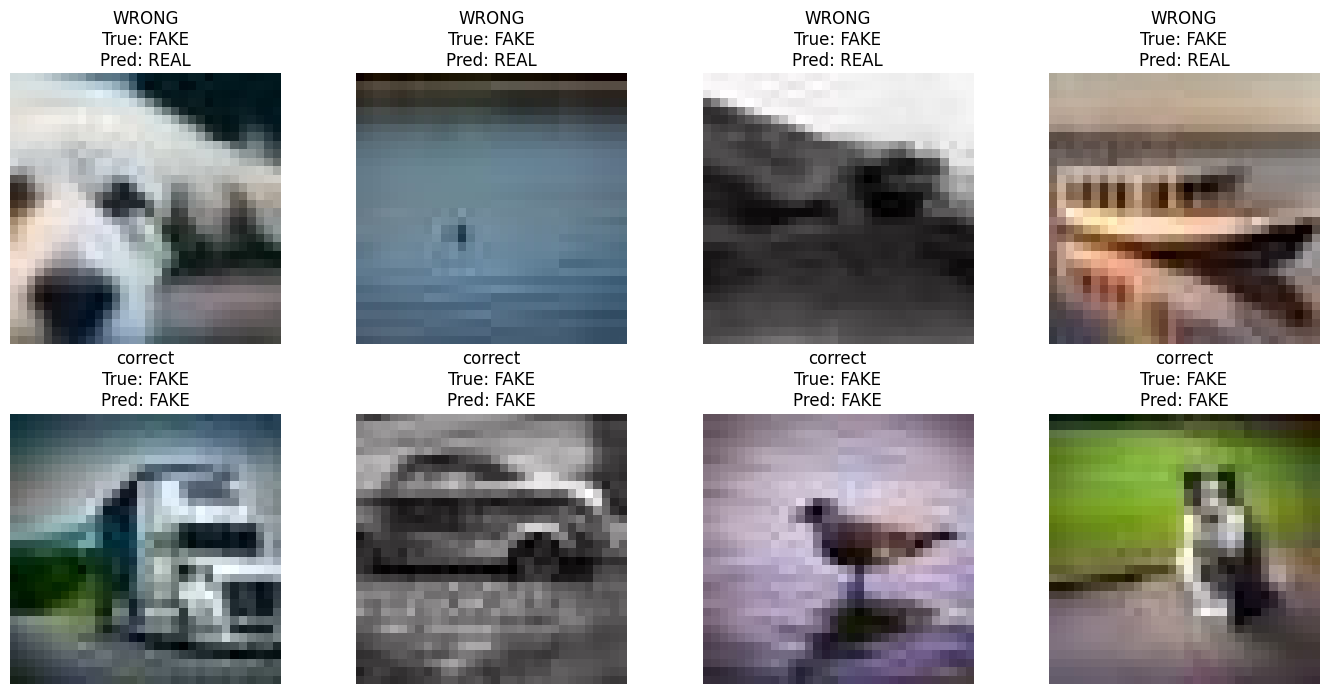

In [7]:
model.eval()
misclassified = []
correct_examples = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(images)):
            if predicted[i] != labels[i] and len(misclassified) < 4:
                misclassified.append((images[i].cpu(), labels[i].item(), predicted[i].item()))
            elif predicted[i] == labels[i] and len(correct_examples) < 4:
                correct_examples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))
        if len(misclassified) >= 4 and len(correct_examples) >= 4:
            break

combined = misclassified + correct_examples

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, (img, true_label, pred_label) in enumerate(combined):
    ax = axes[i // 4, i % 4]
    ax.imshow(img.permute(1, 2, 0))
    tag = "WRONG" if i < 4 else "correct"
    ax.set_title(f"{tag}\nTrue: {train_dataset.classes[true_label]}\nPred: {train_dataset.classes[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

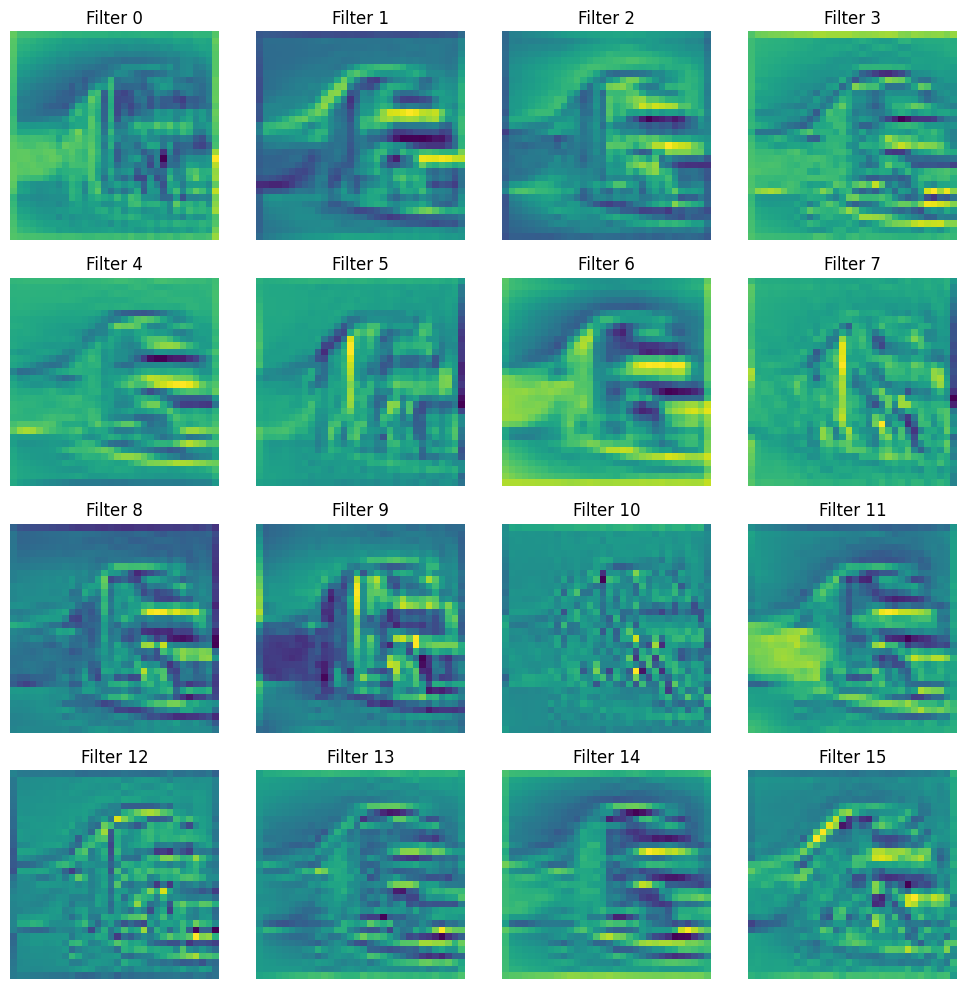

In [8]:
img, label = test_dataset[0]
img_input = img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    feature_maps = model.conv1(img_input)

feature_maps = feature_maps.squeeze(0).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(feature_maps[i], cmap='viridis')
    ax.set_title(f"Filter {i}")
    ax.axis('off')
plt.tight_layout()
plt.show()